Index(['FSA', 'n_days', 'concentration', 'longitude', 'latitude',
       'hous_frac_type_single_detached', 'hous_frac_type_highrise',
       'hous_frac_type_other_attached', 'hous_frac_type_movable',
       'hous_avg_rooms', 'hous_frac_major_repair', 'hous_frac_age_pre_1980',
       'hous_frac_age_1981_2000', 'hous_frac_age_post_2001',
       'hous_median_value', 'demogr_pop_2016', 'demogr_num_total_dwellings',
       'demogr_num_occ_dwellings', 'demogr_median_age',
       'demogr_avg_household_size', 'demogr_frac_tenure_owned',
       'demogr_frac_tenure_rented', 'demogr_frac_tenure_band',
       'socioeco_frac_low_income', 'socioeco_median_income',
       'socioeco_frac_high_income', 'socioeco_frac_govt_transfers',
       'socioeco_frac_unemployment_rate', 'socioeco_frac_nonlaborer',
       'socioeco_frac_bachelor_plus', 'socioeco_frac_overcrowded',
       'socioeco_frac_unsuitable_housing', 'socioeco_frac_housing_burden',
       'rxtp_intrusive_rocks', 'rxtp_metamorphic_rocks',
    

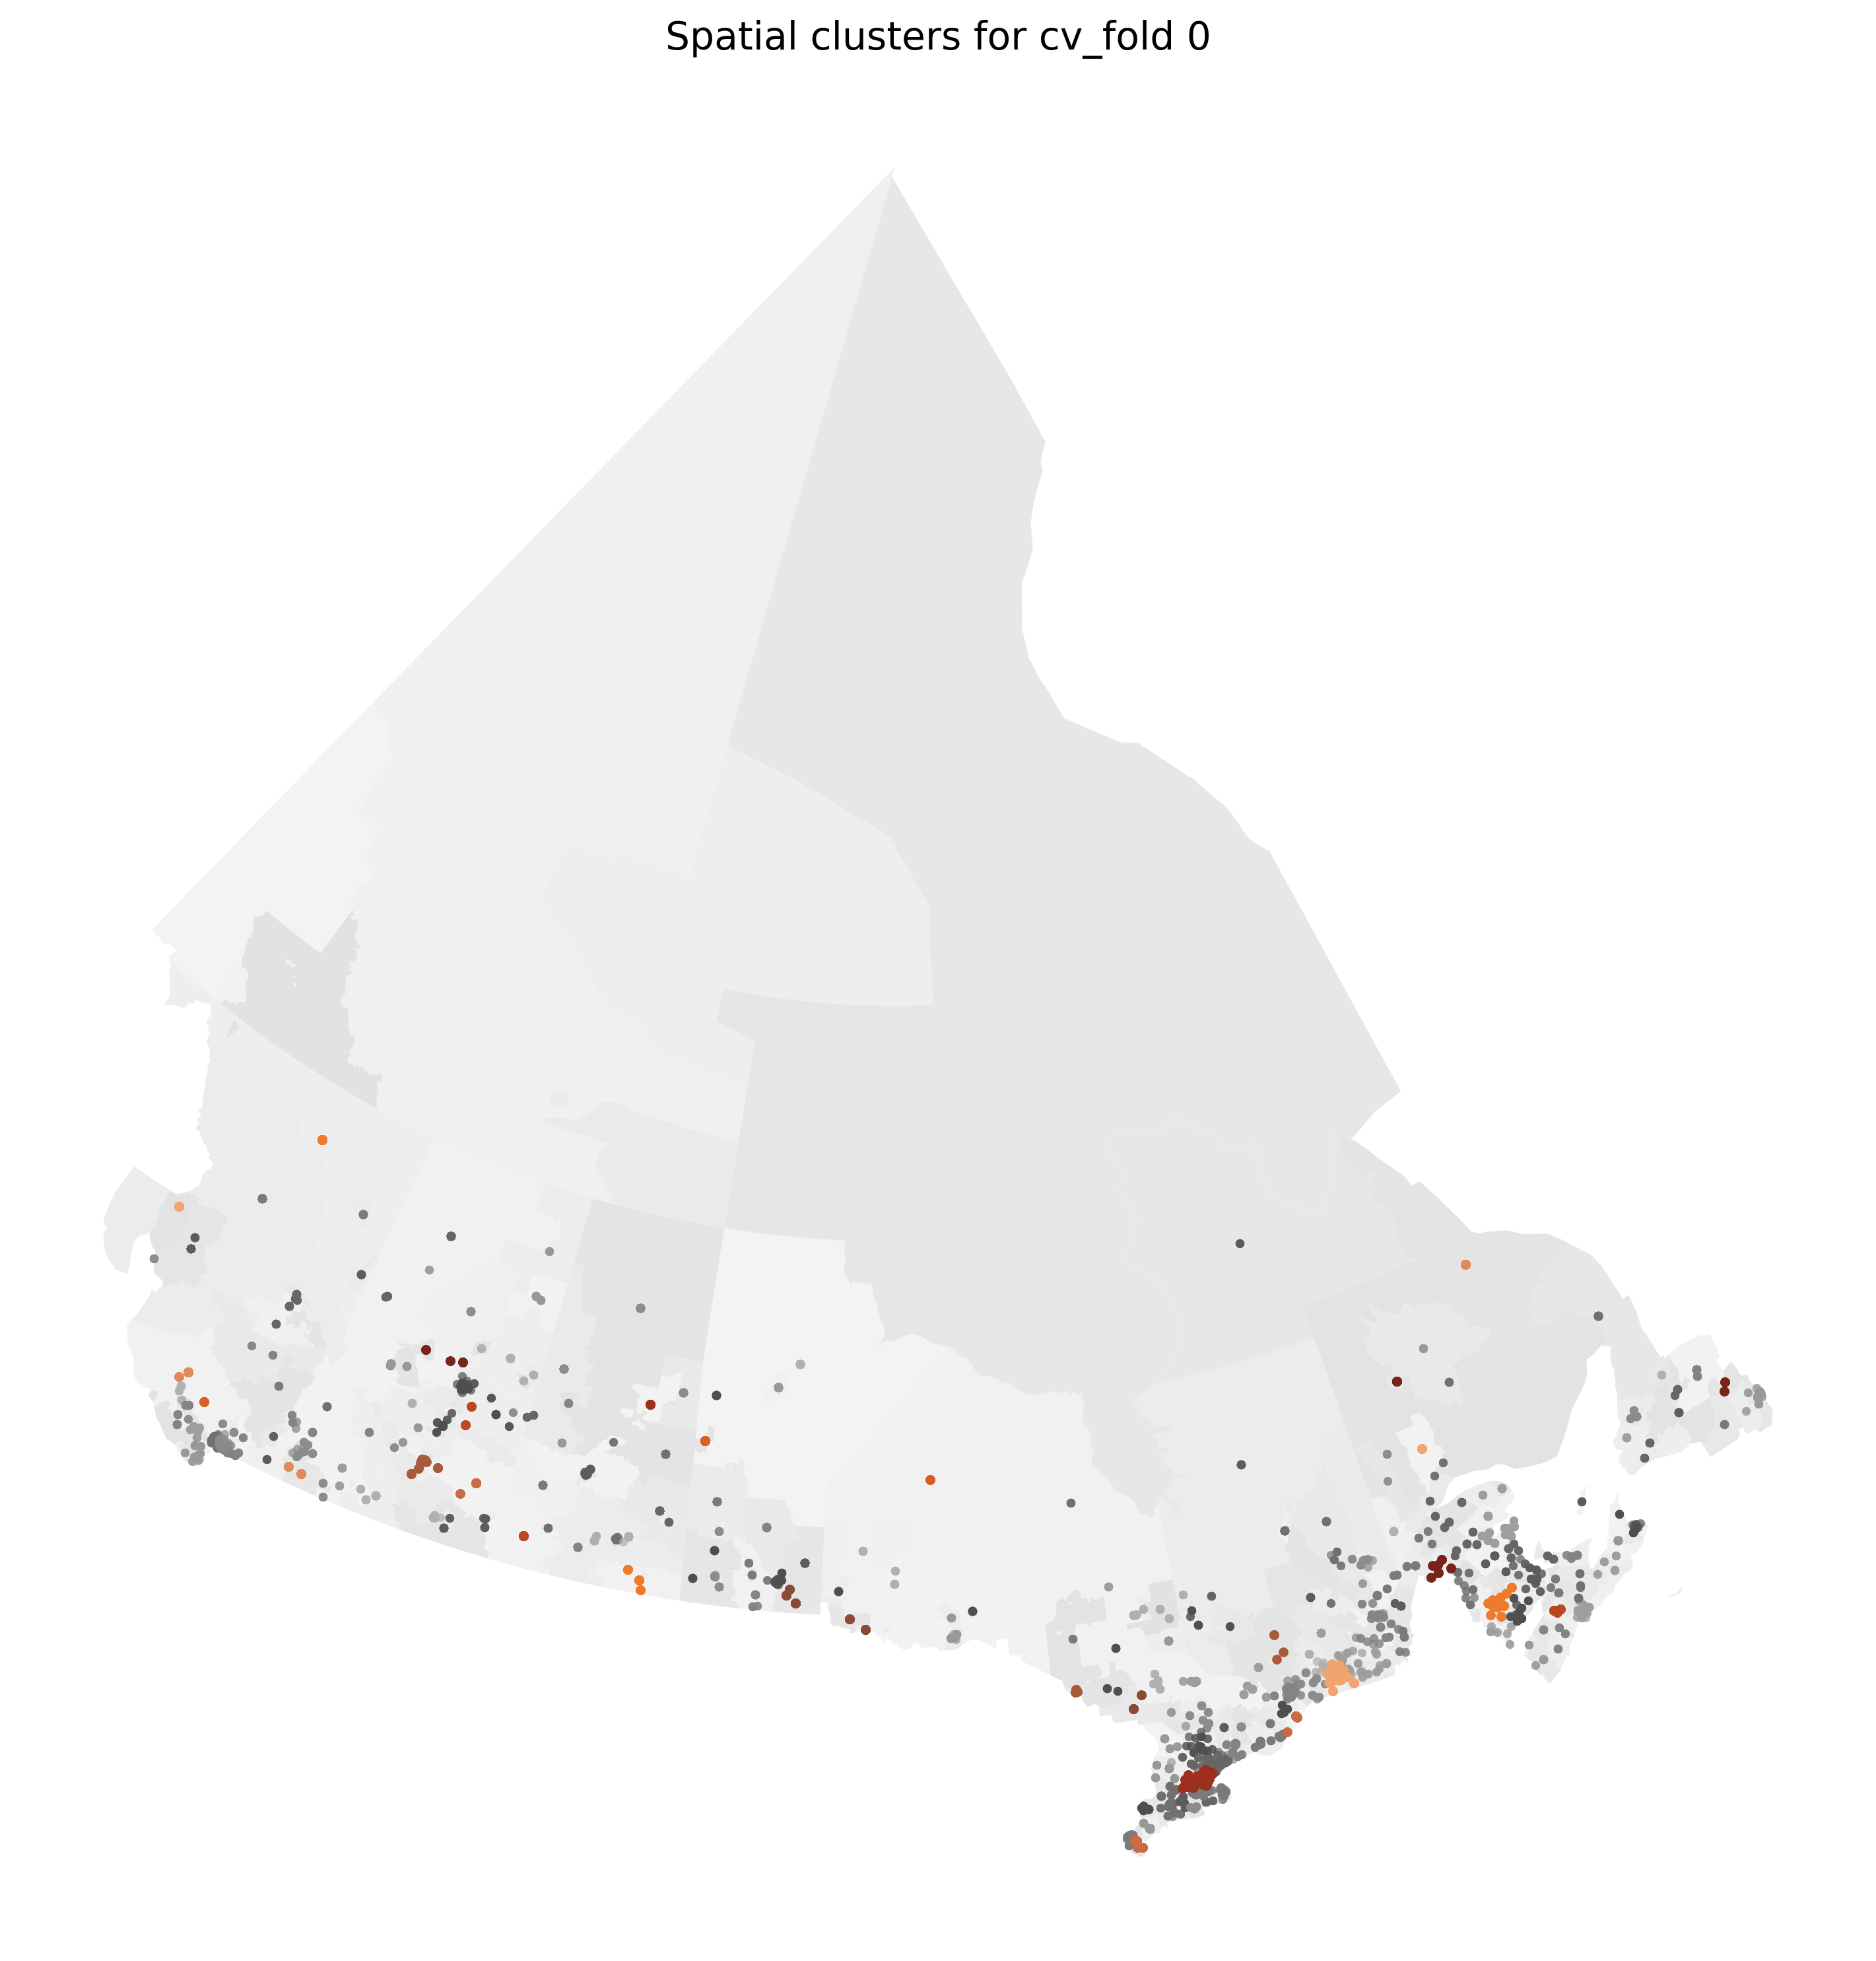

In [1]:
from pathlib import Path
import sys
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# ------------------------------------------------------------
# Project imports
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config.paths import FSA_BOUNDARY_SHAPEFILE, FIGURES_DIR

from src.data.data_loading import (
    load_full_dataset,
    load_full_training_pool,
    load_test_data,
    load_training_data,
    load_validation_data
)

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
fold_to_highlight = 0

longitude_column = "longitude"
latitude_column = "latitude"
cluster_column = "spatial_cluster"
cv_fold_column = "cv_fold"

point_size_other_folds = 10
point_size_highlight = 12

point_size_background = 10
background_alpha = 0.45
highlight_alpha = 0.95

# ------------------------------------------------------------
# Load point data
# Choose whichever loader is appropriate for your workflow
# ------------------------------------------------------------
data = load_full_dataset().copy()

# Optional sanity checks
required_columns = [
    longitude_column,
    latitude_column,
    cluster_column,
    cv_fold_column
]
print(data.columns)
missing_columns = [column for column in required_columns if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Drop rows with missing coordinates or labels
data = data.dropna(
    subset=[longitude_column, latitude_column, cluster_column, cv_fold_column]
).copy()

# ------------------------------------------------------------
# Convert points to GeoDataFrame
# ------------------------------------------------------------
points_gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data[longitude_column], data[latitude_column]),
    crs="EPSG:4326"
)

# Reproject to match the map CRS we want to use
points_gdf = points_gdf.to_crs("EPSG:3347")

# Split into highlighted fold and all others
highlight_points = points_gdf[points_gdf[cv_fold_column] == fold_to_highlight].copy()
other_points = points_gdf[points_gdf[cv_fold_column] != fold_to_highlight].copy()

if len(highlight_points) == 0:
    raise ValueError(f"No rows found for cv_fold = {fold_to_highlight}")

# ------------------------------------------------------------
# Load FSA polygons
# ------------------------------------------------------------
fsa_boundaries = gpd.read_file(FSA_BOUNDARY_SHAPEFILE)

if fsa_boundaries.crs is None:
    raise ValueError("The FSA shapefile CRS is missing.")

fsa_boundaries = fsa_boundaries.to_crs("EPSG:3347")

# ------------------------------------------------------------
# Make a very pale, low-contrast grayscale background
# ------------------------------------------------------------
# Assign random-but-fixed pale values just to vary polygons slightly
rng = np.random.default_rng(42)
fsa_boundaries = fsa_boundaries.copy()
fsa_boundaries["gray_value"] = 0.1 + 0.1 * rng.random(len(fsa_boundaries))

# ------------------------------------------------------------
# Build cluster colors for highlighted fold
# Cyan-ish, not super saturated
# ------------------------------------------------------------
unique_clusters = sorted(highlight_points[cluster_column].unique())

# These are deliberately muted cyan/teal/aqua-ish tones
cyanish_palette = [
    "#2E6F77",
    "#3E8F97",
    "#58AEB8",
    "#79C9D4",
    "#4D8E7F",
    "#6EAAA8",
    "#8FC9BF",
    "#3F7FA8",
    "#6FAFC8",
    "#A7D9DE",
]
cyanish_palette= [
    "#8C2D1E",
    "#B23A1B",
    "#CC4E1A",
    "#E1641E",
    "#F07C28",
    "#A3472B",
    "#C65D3A",
    "#D9774A",
    "#8F4C38",
    "#F29A5B",
]
cluster_focus_palette  = [
    "#7A2318",
    "#9C2F1D",
    "#BD4721",
    "#D85F24",
    "#F07A2A",
    "#A95A3A",
    "#C96B44",
    "#E08A5B",
    "#8A4A34",
    "#F2A46E",
]

# If there are more clusters than colors, cycle through palette
cluster_to_color = {
    cluster_value: cluster_focus_palette[i % len(cluster_focus_palette)]
    for i, cluster_value in enumerate(unique_clusters)
}



# ------------------------------------------------------------
# Background grayscale colors for non-highlighted folds
# ------------------------------------------------------------
other_clusters = sorted(other_points[cluster_column].unique())

other_cluster_palette = [
    "#4F4F4F",
    "#666666",
    "#7A7A7A",
    "#8C8C8C",
    "#9E9E9E",
    "#B0B0B0",
    "#5C5C5C",
    "#707070",
    "#848484",
    "#989898",
]

other_cluster_to_color = {
    cluster_value: other_cluster_palette[i % len(other_cluster_palette)]
    for i, cluster_value in enumerate(other_clusters)
}



highlight_points["plot_color"] = highlight_points[cluster_column].map(cluster_to_color)

# ------------------------------------------------------------
# Muted complementary background color for non-highlighted folds
# Warm gray / dusty mauve-brown-ish, intentionally subdued
# ------------------------------------------------------------
other_points_color = "#9A8F8A"

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Pale grayscale FSA background
fsa_boundaries.plot(
    column="gray_value",
    cmap="Greys",
    vmin=0.0,
    vmax=1.0,
    linewidth=0,
    edgecolor=(1, 1, 1, 0.35),
    legend=False,
    ax=ax
)

# Other folds: muted and less eye-catching
for cluster_value in other_clusters:
    cluster_subset = other_points[other_points[cluster_column] == cluster_value]

    cluster_subset.plot(
        ax=ax,
        color=other_cluster_to_color[cluster_value],
        markersize=point_size_other_folds,
        alpha=background_alpha,
        linewidth=0
    )

# Highlight fold: plot each cluster in its own cyan-ish color
for cluster_value in unique_clusters:
    cluster_subset = highlight_points[highlight_points[cluster_column] == cluster_value]

    cluster_subset.plot(
        ax=ax,
        color=cluster_to_color[cluster_value],
        markersize=point_size_highlight,
        alpha=highlight_alpha,
        linewidth=0,
        label=f"Cluster {cluster_value}"
    )

ax.set_title(
    f"Spatial clusters for cv_fold {fold_to_highlight}",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

# # Optional legend
# ax.legend(
#     loc="upper right",
#     frameon=True,
#     facecolor="white",
#     edgecolor="none",
#     fontsize=9,
#     title="Highlighted fold clusters",
#     title_fontsize=10
# )

plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "spatial_clusters_cvfold_map.png"), dpi=300, bbox_inches="tight")
plt.show()